# Monte Carlo v3 -- design distributions (meeting prep)

Plots only, no pipeline code yet. Turbine set first, then the two time distributions we're deciding between.

In [1]:
from pathlib import Path
import yaml
import numpy as np
import matplotlib.pyplot as plt
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine

DATA_DIR = (Path("..") / ".." / "Data").resolve()
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

/opt/anaconda3/envs/Wind_2200/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Turbine set -- power curves and spacing range

In [2]:
TURBINE_FILES = {"11 MW": "sg11_200dd.yaml", "13 MW": "haliadex_13mw.yaml",
                  "15.5 MW": "haliadex_15.5.yaml", "22 MW": "turbines.yaml"}

def load_turbine(fname):
    d = yaml.safe_load(open(DATA_DIR / fname))
    perf = d["performance"]
    ws = np.array(perf["power_curve"]["power_wind_speeds"])
    p = np.array(perf["power_curve"]["power_values"]) / 1e6
    return dict(diameter=d["rotor_diameter"], rated_mw=perf["rated_power"] / 1e6, ws=ws, power_mw=p)

def build_generic(rated_mw, diameter, hub_height, ws_cutin=3.0, ws_cutout=25.0, step=0.5):
    t = GenericWindTurbine(name=f"Generic {rated_mw:.0f}MW", diameter=diameter, hub_height=hub_height,
                            power_norm=rated_mw * 1000, ws_cutin=ws_cutin, ws_cutout=ws_cutout)
    ws = np.arange(ws_cutin, ws_cutout + 1e-6, step)
    return dict(diameter=diameter, rated_mw=rated_mw, ws=ws, power_mw=t.power(ws) / 1e6)

turbines = {label: load_turbine(fname) for label, fname in TURBINE_FILES.items()}
turbines["18 MW (new)"] = build_generic(18.0, 263.0, 171.0)  # diameter/hub interpolated from the real 15.5/22MW trend
turbines = dict(sorted(turbines.items(), key=lambda kv: kv[1]["rated_mw"]))

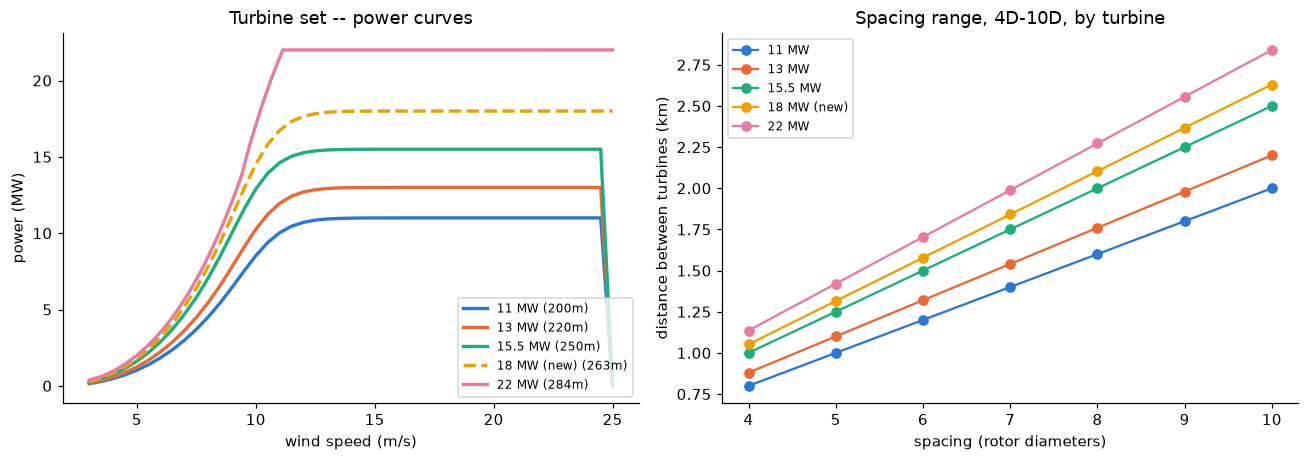

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

for (name, t), c in zip(turbines.items(), COLORS):
    style = "--" if "new" in name else "-"
    ax1.plot(t["ws"], t["power_mw"], style, color=c, linewidth=2.2, label=f"{name} ({t['diameter']:.0f}m)")
ax1.set_xlabel("wind speed (m/s)")
ax1.set_ylabel("power (MW)")
ax1.set_title("Turbine set -- power curves")
ax1.legend(fontsize=8, loc="lower right")

spacing_d = np.arange(4, 10.5, 1)
for (name, t), c in zip(turbines.items(), COLORS):
    ax2.plot(spacing_d, spacing_d * t["diameter"] / 1000, "o-", color=c, label=name)
ax2.set_xlabel("spacing (rotor diameters)")
ax2.set_ylabel("distance between turbines (km)")
ax2.set_title("Spacing range, 4D-10D, by turbine")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 2. Turbine choice over time -- 3 candidate shapes

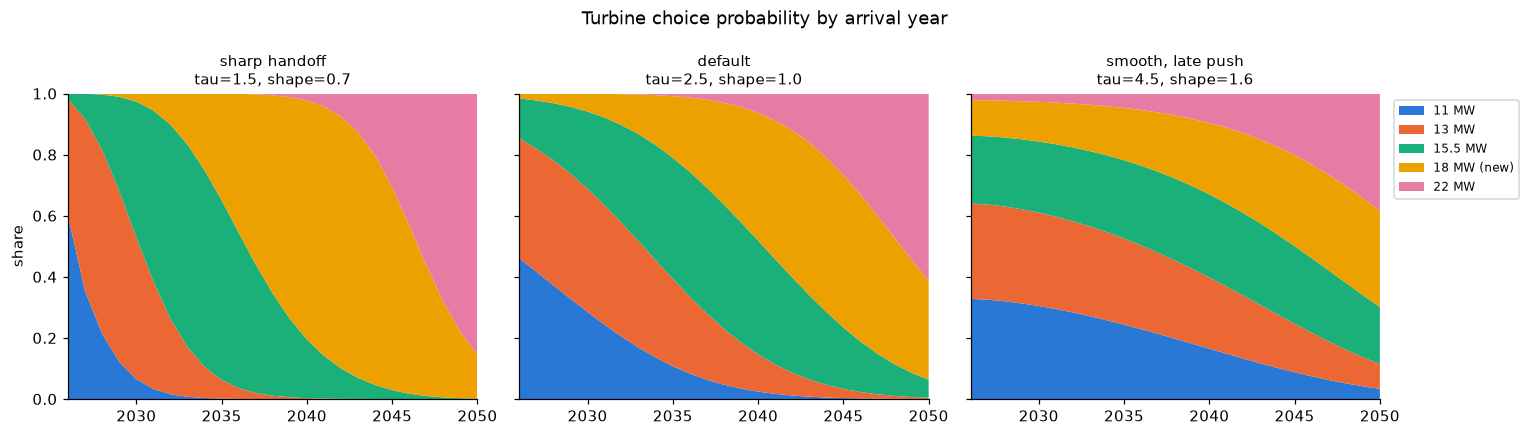

In [4]:
RATINGS = np.array([t["rated_mw"] for t in turbines.values()])
LABELS = list(turbines.keys())
Y0, Y1 = 2026, 2050
YEARS = np.arange(Y0, Y1 + 1)

def typical_rating(year, shape, r0=11.5, r1=21.0):
    frac = (year - Y0) / (Y1 - Y0)
    return r0 + (r1 - r0) * frac ** shape

def shares(year, tau, shape):
    target = typical_rating(year, shape)
    w = np.exp(-((target - RATINGS) ** 2) / (2 * tau ** 2))
    return w / w.sum()

configs = [("sharp handoff", 1.5, 0.7), ("default", 2.5, 1.0), ("smooth, late push", 4.5, 1.6)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (label, tau, shape) in zip(axes, configs):
    S = np.array([shares(y, tau, shape) for y in YEARS])
    ax.stackplot(YEARS, S.T, colors=COLORS, labels=LABELS)
    ax.set_title(f"{label}\ntau={tau}, shape={shape}", fontsize=10)
    ax.set_xlim(Y0, Y1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("share")
axes[-1].legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
fig.suptitle("Turbine choice probability by arrival year")
fig.tight_layout()
plt.show()

## 3. Farm arrival timing, N=15 -- S-curve, 3 shapes

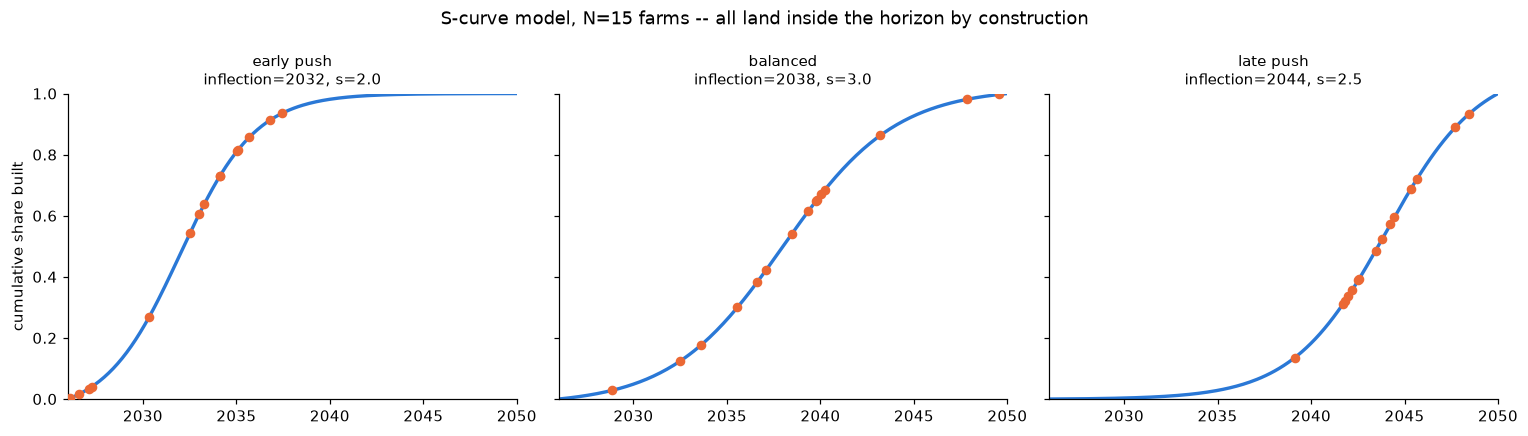

In [5]:
N = 15
T = Y1 - Y0

def sigmoid(t, t_mid, s):
    return 1 / (1 + np.exp(-(t - t_mid) / s))

def F(t, t_mid, s):
    a, b = sigmoid(0, t_mid, s), sigmoid(T, t_mid, s)
    return (sigmoid(t, t_mid, s) - a) / (b - a)

def inv_F(p, t_mid, s):
    a, b = sigmoid(0, t_mid, s), sigmoid(T, t_mid, s)
    target = np.clip(a + p * (b - a), 1e-9, 1 - 1e-9)
    return t_mid - s * np.log(1 / target - 1)

s_configs = [("early push", 2032 - Y0, 2.0), ("balanced", 2038 - Y0, 3.0), ("late push", 2044 - Y0, 2.5)]
tt = np.linspace(0, T, 200)
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (label, t_mid, s) in zip(axes, s_configs):
    ax.plot(tt + Y0, F(tt, t_mid, s), color=COLORS[0], linewidth=2.2)
    ps = np.sort(rng.uniform(size=N))
    arrival_years = inv_F(ps, t_mid, s) + Y0
    ax.scatter(arrival_years, F(arrival_years - Y0, t_mid, s), color=COLORS[1], zorder=5, s=28)
    ax.set_title(f"{label}\ninflection={t_mid + Y0:.0f}, s={s}", fontsize=10)
    ax.set_xlim(Y0, Y1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("cumulative share built")
fig.suptitle(f"S-curve model, N={N} farms -- all land inside the horizon by construction")
fig.tight_layout()
plt.show()

## 4. Accelerating exponential growth (convex), N=15 -- 3 rates

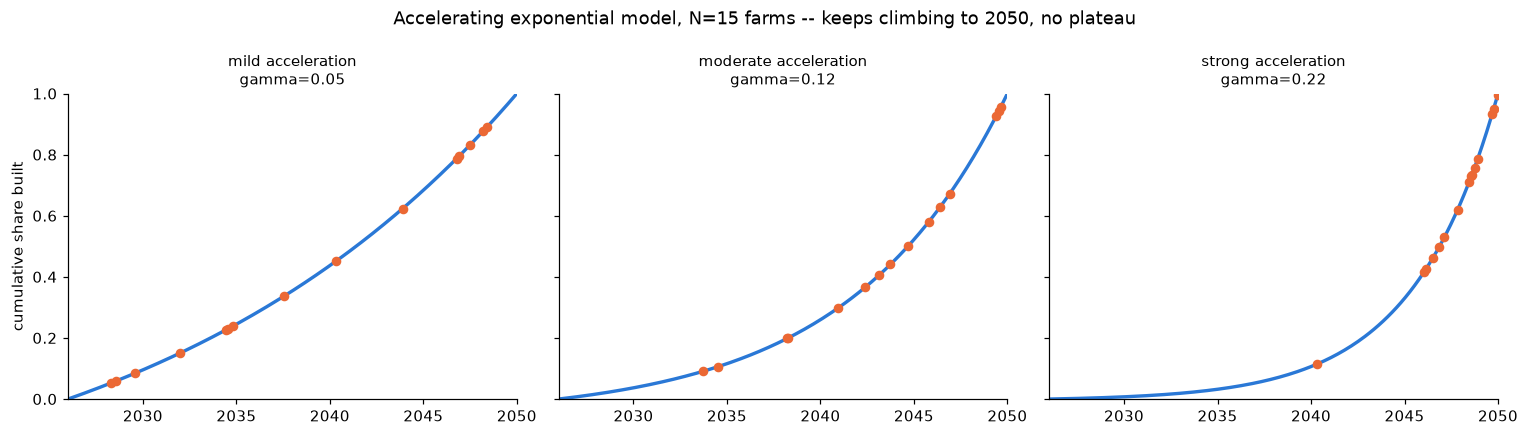

In [6]:
def F_exp(t, gamma):
    return (np.exp(gamma * t) - 1) / (np.exp(gamma * T) - 1)

def inv_F_exp(u, gamma):
    return (1 / gamma) * np.log(1 + u * (np.exp(gamma * T) - 1))

exp_configs = [("mild", 0.05), ("moderate", 0.12), ("strong", 0.22)]  # gamma, 1/yr

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (label, gamma) in zip(axes, exp_configs):
    ax.plot(tt + Y0, F_exp(tt, gamma), color=COLORS[0], linewidth=2.2)
    us = np.sort(rng.uniform(size=N))
    arrival_years = inv_F_exp(us, gamma) + Y0
    ax.scatter(arrival_years, F_exp(arrival_years - Y0, gamma), color=COLORS[1], zorder=5, s=28)
    ax.set_title(f"{label} acceleration\ngamma={gamma}", fontsize=10)
    ax.set_xlim(Y0, Y1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("cumulative share built")
fig.suptitle(f"Accelerating exponential model, N={N} farms -- keeps climbing to 2050, no plateau")
fig.tight_layout()
plt.show()

## 5. S-curve vs. accelerating exponential -- side by side

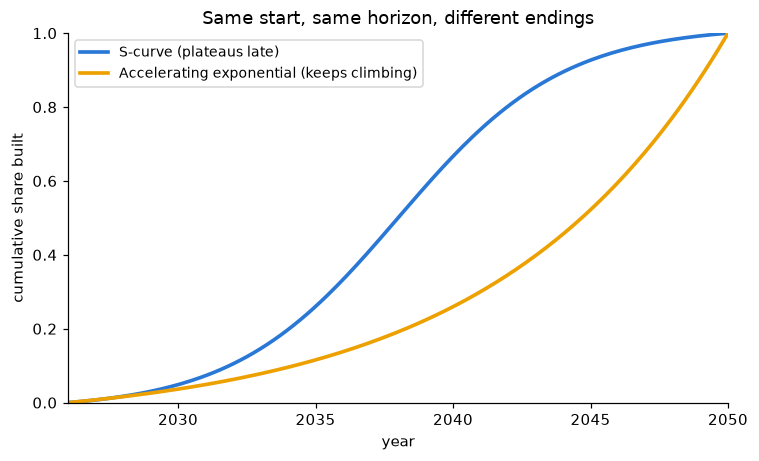

In [7]:
t_mid_ref, s_ref = 2038 - Y0, 3.0
gamma_ref = 0.12

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(tt + Y0, F(tt, t_mid_ref, s_ref), color=COLORS[0], linewidth=2.4, label="S-curve (plateaus late)")
ax.plot(tt + Y0, F_exp(tt, gamma_ref), color=COLORS[3], linewidth=2.4, label="Accelerating exponential (keeps climbing)")
ax.set_xlim(Y0, Y1)
ax.set_ylim(0, 1)
ax.set_xlabel("year")
ax.set_ylabel("cumulative share built")
ax.legend(fontsize=9)
ax.set_title("Same start, same horizon, different endings")
fig.tight_layout()
plt.show()